# 07b · Pain phenotypes on the full 1,485-patient cohort

Notebook 07 had cells of n=1–17 in the matched 74-patient subset. Here we project phenotype flags onto the full PPMI cohort (patient-anchor rel frame) + compute the same per-patient Δpain on the larger pool. Stratify worsening by phenotype × DBS.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(stringr); library(purrr); library(broom) })

pheno_df <- readRDS(file.path(OUT_OBJ, "pain_phenotype_flags.rds"))
rel <- load_full_ppmi_rel_patient_anchor()

feat <- build_per_patient_features(rel, var = "NP1PAIN",
                                   pre_win = c(-24, 0), post_win = c(6, 18))
arm <- rel %>% dplyr::distinct(PATNO, will_receive_dbs)
dat <- feat %>% dplyr::inner_join(arm, by = "PATNO") %>%
  dplyr::left_join(pheno_df, by = "PATNO") %>%
  dplyr::mutate(dplyr::across(dplyr::any_of(names(PAIN_PHENOTYPE_PATTERNS)),
                              ~ dplyr::coalesce(.x, FALSE)))
cat("Full-cohort analytic n:", nrow(dat), "\n")
print(dplyr::count(dat, will_receive_dbs, worsened))

Warning message:
“package ‘broom’ was built under R version 4.5.2”


Full-cohort analytic n: 642 


# A tibble: 4 × 3
  will_receive_dbs worsened     n
  <lgl>               <int> <int>
1 FALSE                   0   485
2 FALSE                   1    90
3 TRUE                    0    56
4 TRUE                    1    11


In [2]:
summ <- purrr::map_dfr(names(PAIN_PHENOTYPE_PATTERNS), function(ph) {
  d <- dat %>% dplyr::filter(.data[[ph]])
  if (nrow(d) == 0) return(tibble::tibble(phenotype = ph, will_receive_dbs = NA,
                                          n = 0, mean_delta = NA, pct_worsen = NA))
  d %>% dplyr::group_by(will_receive_dbs) %>%
    dplyr::summarise(n = dplyr::n(), mean_delta = mean(delta),
                     pct_worsen = mean(worsened == 1), .groups = "drop") %>%
    dplyr::mutate(phenotype = ph, .before = 1)
})
print(summ)
save_table(summ, "pain_phenotype_full_cohort_summary")

# A tibble: 11 × 5
   phenotype       will_receive_dbs     n mean_delta pct_worsen
   <chr>           <lgl>            <int>      <dbl>      <dbl>
 1 musculoskeletal FALSE              129     0.0542      0.147
 2 musculoskeletal TRUE                25     0.181       0.2  
 3 neuropathic     FALSE               37     0.0688      0.216
 4 neuropathic     TRUE                 8     0.185       0.125
 5 dystonic        FALSE               12     0.0884      0.167
 6 dystonic        TRUE                 3     0.0357      0    
 7 central         FALSE                1    -0.118       0    
 8 headache        FALSE               16    -0.285       0.188
 9 headache        TRUE                 5    -0.650       0    
10 visceral        FALSE               12     0.247       0.333
11 visceral        TRUE                 3    -0.413       0    


In [3]:
# Logistic: worsened ~ DBS × phenotype (one model per phenotype)
fit_one <- function(ph) {
  d <- dat %>% dplyr::mutate(dbs = as.integer(will_receive_dbs),
                             has_pheno = as.integer(.data[[ph]])) %>%
    tidyr::drop_na(worsened, dbs, has_pheno)
  f <- tryCatch(stats::glm(worsened ~ dbs * has_pheno, data = d, family = "binomial"),
                error = function(e) NULL)
  if (is.null(f)) return(tibble::tibble(phenotype = ph, term = NA, OR = NA, p = NA))
  broom::tidy(f, conf.int = TRUE, exponentiate = TRUE) %>%
    dplyr::mutate(phenotype = ph, .before = 1)
}
interactions <- purrr::map_dfr(names(PAIN_PHENOTYPE_PATTERNS), fit_one) %>%
  dplyr::filter(term == "dbs:has_pheno")
print(interactions)
save_table(interactions, "pain_phenotype_dbs_interactions")

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


...

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


# A tibble: 6 × 8
  phenotype       term   estimate std.error statistic p.value conf.low conf.high
  <chr>           <chr>     <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 musculoskeletal dbs:h…  1.64e+0     0.723    0.688    0.492   0.385    6.86e 0
2 neuropathic     dbs:h…  4.56e-1     1.20    -0.654    0.513   0.0213   3.65e 0
3 dystonic        dbs:h…  2.11e-6   510.      -0.0256   0.980  NA        2.22e30
4 central         dbs:h… NA          NA       NA       NA      NA       NA      
5 headache        dbs:h…  6.43e-7   651.      -0.0219   0.983  NA        8.86e31
6 visceral        dbs:h…  8.20e-7   510.      -0.0275   0.978  NA        2.33e22


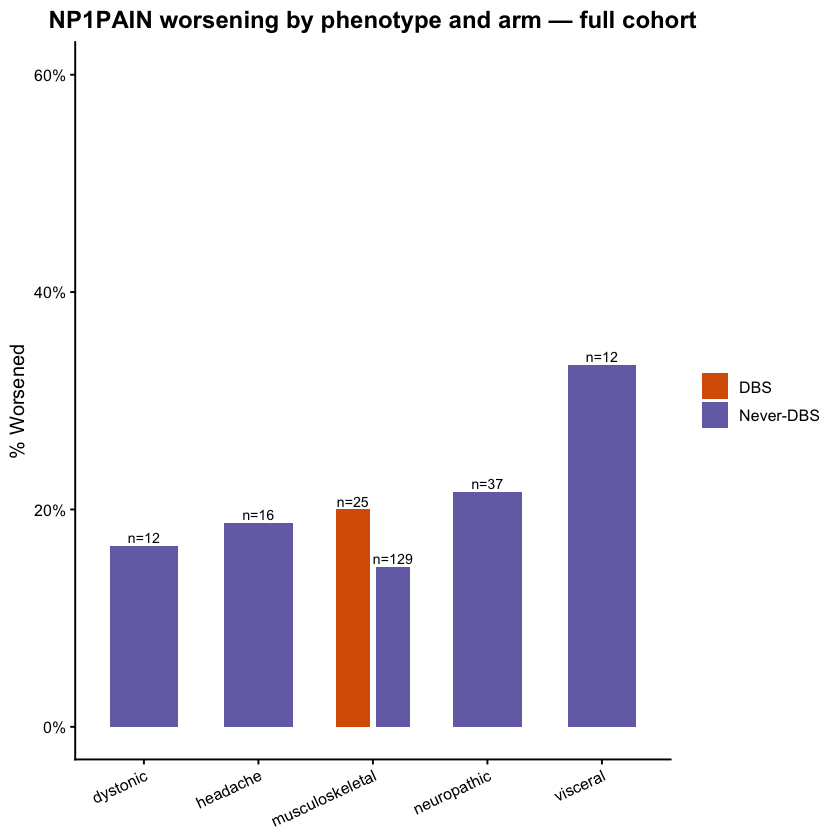

In [4]:
pl <- summ %>% dplyr::filter(!is.na(will_receive_dbs), n >= 10) %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
p_phe <- ggplot(pl, aes(x = phenotype, y = pct_worsen, fill = arm)) +
  geom_col(position = position_dodge(0.7), width = 0.6) +
  geom_text(aes(label = sprintf("n=%d", n)), position = position_dodge(0.7),
            vjust = -0.3, size = 3) +
  scale_y_continuous("% Worsened", labels = scales::percent_format(), limits = c(0, 0.6)) +
  scale_fill_manual(values = c(`DBS` = "#d95f02", `Never-DBS` = "#7570b3"), name = NULL) +
  labs(title = "NP1PAIN worsening by phenotype and arm — full cohort", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 25, hjust = 1))
p_phe
save_fig(p_phe, "Fig15b_pain_phenotype_full_cohort", width = 8.5, height = 4.4)